In [ ]:
import os
import ee
import geemap
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from scipy.ndimage import zoom
from tensorflow.keras import layers, models

In [ ]:
def earth_engine():

    load_dotenv()

    print("Dotenv loaded successfully")

    project_id = os.getenv("GEE_PROJECT_ID")

    try:
        ee.Initialize(project=project_id)
        print(f"Earth Engine initialized with project: {project_id}")

    except Exception:

        print("Authentication required...")

        ee.Authenticate(force=True, auth_mode='notebook')

        ee.Initialize(project=project_id)

    return project_id
project_id = earth_engine()
project_id

Dotenv loaded successfully
Earth Engine initialized with project: aravalli-mining-detector


'aravalli-mining-detector'

In [ ]:
# ------------------------------------------------
# 1. Classification Model (Updated to match training)
# ------------------------------------------------
def build_improved_classification_model(input_shape=(7, 64, 64, 4), num_classes=3):
    inputs = layers.Input(shape=input_shape)

    # --- Block 1: Basic Spatial Features ---
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))(inputs)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)

    # --- Block 2: Deeper Spatial Features ---
    x = layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)

    # --- Block 3: Final Spatial Compression ---
    x = layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x) 

    # --- Temporal Processing (LSTM with Dropout) ---
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x) 

    # --- Attention Mechanism ---
    att_weights = layers.Dense(1)(x)
    att_weights = layers.Softmax(axis=1)(att_weights)
    x_weighted = layers.Multiply()([x, att_weights])
    x_final = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x_weighted)

    # --- Classification Head ---
    x = layers.Dense(64, activation='relu', kernel_regularizer='l2')(x_final)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="class_output")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ------------------------------------------------
# 2. Regression Model (keep as before)
# ------------------------------------------------
def build_regression_model_with_attention(input_shape=(7, 64, 64, 4)):
    inputs = layers.Input(shape=input_shape)
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))(inputs)
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=True)(x)
    x = layers.BatchNormalization()(x)

    time_steps = input_shape[0]
    x_reshaped = layers.Reshape((time_steps, -1))(x)
    scores = layers.TimeDistributed(layers.Dense(1))(x_reshaped)
    scores = layers.Flatten()(scores)
    weights = layers.Activation('softmax')(scores)
    weights = layers.Reshape((time_steps, 1))(weights)
    context_vector = layers.Multiply()([x_reshaped, weights])
    x_final = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_vector)

    x = layers.Dense(128, activation='relu')(x_final)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='linear', dtype='float32')(x)
    model = models.Model(inputs, output)
    return model
print("Loading Aravali Monitoring Models...")
class_model = build_improved_classification_model()
class_model.load_weights("aravli_classifier_v2.weights.h5") 

reg_model = build_regression_model_with_attention()
reg_model.load_weights("aravali_forest_model_v2.weights.h5")
print("✅ Models ready for inference.")


def get_gee_sequence(lat, lon):
    point = ee.Geometry.Point([lon, lat])
    region = point.buffer(320).bounds()
    years = range(2020, 2027)
    sequence = []

    for year in years:
        img = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
               .filterBounds(region)
               .filterDate(f"{year}-01-01", f"{year}-03-31")
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
               .median()
               .select(['B4','B3','B2','B8'])
               .clip(region))

        patch = geemap.ee_to_numpy(img, region=region, scale=10)
        if patch.shape[:2] != (64, 64):
            patch = zoom(patch, (64/patch.shape[0], 64/patch.shape[1], 1))
        sequence.append(patch)

    return np.array(sequence)

Loading Aravali Monitoring Models...
✅ Models ready for inference.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

--- Analysis for 28.3415, 77.211 ---
Model Classification: Forest
Measured Forest Loss: -0.3071
FINAL ECOLOGICAL STATUS: Degraded/Encroached Forest
Confidence: 92.47%


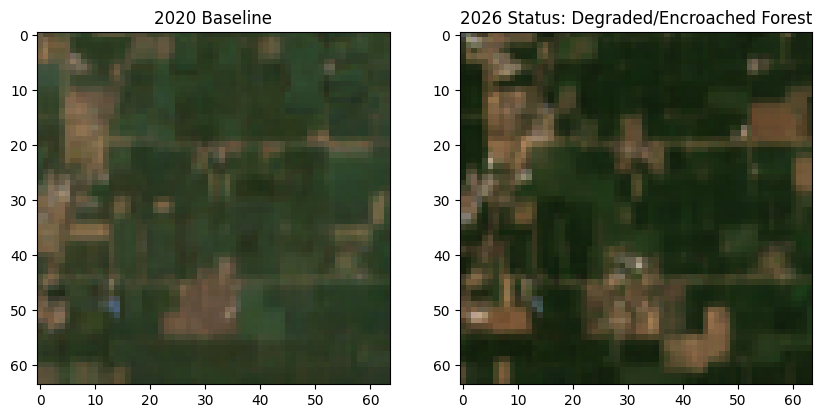

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

--- Analysis for 28.368, 77.241 ---
Model Classification: Scrub Land
Measured Forest Loss: -0.2756
FINAL ECOLOGICAL STATUS: Severe Land Degradation
Confidence: 72.82%


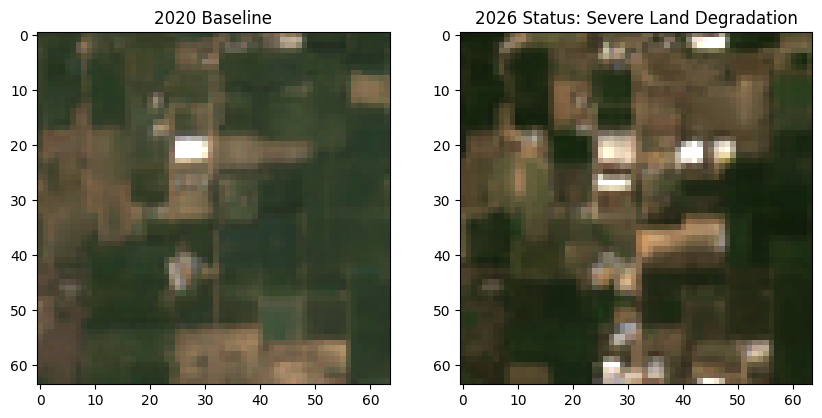

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step

--- Analysis for 28.462, 77.283 ---
Model Classification: Scrub Land
Measured Forest Loss: -0.3186
FINAL ECOLOGICAL STATUS: Severe Land Degradation
Confidence: 91.07%


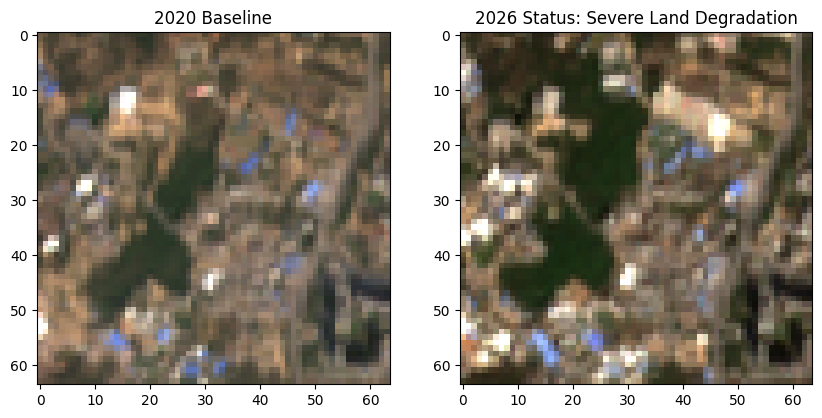

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

--- Analysis for 28.3805, 77.2502 ---
Model Classification: Scrub Land
Measured Forest Loss: -0.2866
FINAL ECOLOGICAL STATUS: Severe Land Degradation
Confidence: 67.63%


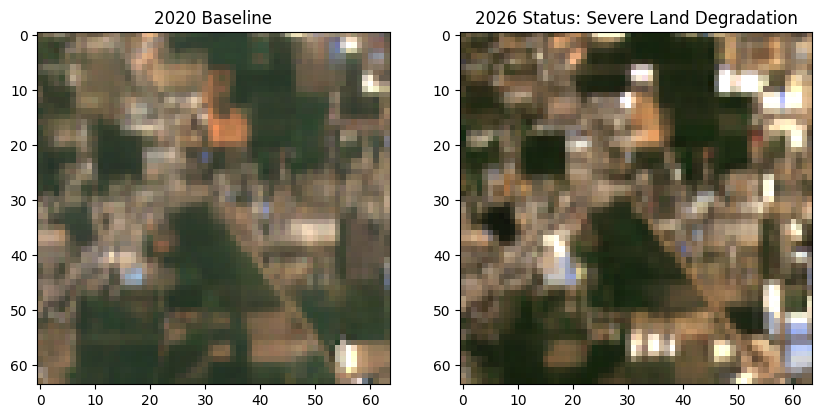

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step

--- Analysis for 28.812, 75.985 ---
Model Classification: Forest
Measured Forest Loss: -0.2953
FINAL ECOLOGICAL STATUS: Degraded/Encroached Forest
Confidence: 75.45%


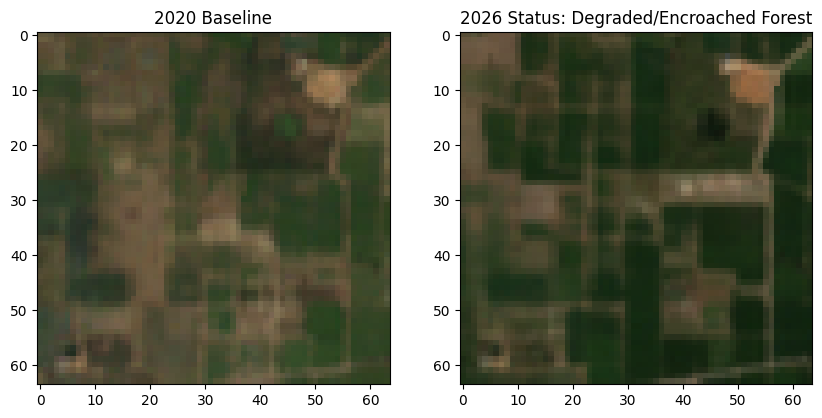

In [ ]:
def run_aravali_test_v2(lat, lon):
    raw_data = get_gee_sequence(lat, lon)
    X_input = raw_data / (np.max(raw_data) + 1e-10)
    X_input = np.expand_dims(X_input, axis=0) 

    class_probs = class_model.predict(X_input)
    loss_val = reg_model.predict(X_input)[0][0] 
    
    class_names = ["Mining/Degradation", "Scrub Land", "Forest"]
    pred_idx = np.argmax(class_probs)
    initial_pred = class_names[pred_idx]

    abs_loss = abs(loss_val)
    if initial_pred == "Forest":
        if abs_loss > 0.15:
            final_status = "Degraded/Encroached Forest"
        else:
            final_status = "Healthy/Stable Forest"    
    elif initial_pred == "Scrub Land":
        if abs_loss > 0.25:
            final_status = "Severe Land Degradation"
        else:
            final_status = "Stable Scrub Land"     
    elif initial_pred == "Mining/Degradation":
        final_status = "Active Quarry/Mined Site"
    else:
        final_status = initial_pred

    print(f"\n--- Analysis for {lat}, {lon} ---")
    print(f"Model Classification: {initial_pred}")
    print(f"Measured Forest Loss: {loss_val:.4f}")
    print(f"FINAL ECOLOGICAL STATUS: {final_status}")
    print(f"Confidence: {np.max(class_probs)*100:.2f}%")

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(np.clip(raw_data[0, :, :, 0:3] / 3000, 0, 1))
    ax[0].set_title("2020 Baseline")
    ax[1].imshow(np.clip(raw_data[-1, :, :, 0:3] / 3000, 0, 1))
    ax[1].set_title(f"2026 Status: {final_status}")
    plt.show()

run_aravali_test_v2(28.3415, 77.211)
run_aravali_test_v2(28.368, 77.241)
run_aravali_test_v2(28.462, 77.283 )
run_aravali_test_v2(28.3805, 77.2502)
run_aravali_test_v2(28.812, 75.985)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

--- Analysis for 27.9421, 77.0355 ---
Model Classification: Forest
Measured Forest Loss: -0.2728
FINAL ECOLOGICAL STATUS: Degraded/Encroached Forest
Confidence: 77.14%


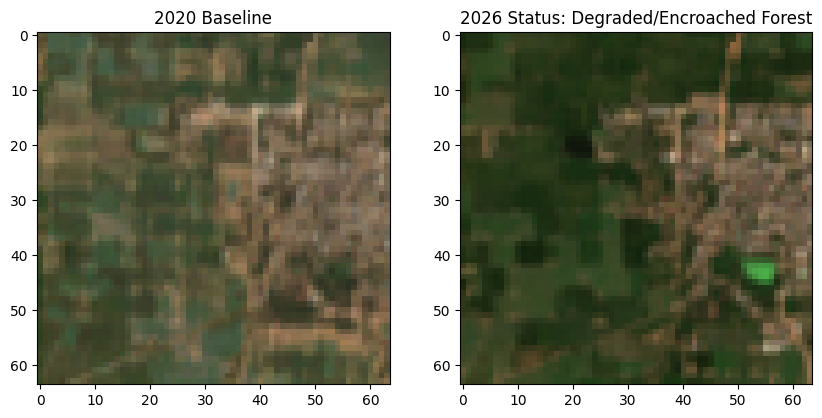

In [25]:
run_aravali_test_v2(27.9421, 77.0355)